Needed to include tf.compat.v1.disable_eager_execution() to work around error "tf.gradients is not supported when eager execution is enabled. Use tf.GradientTape instead"

In [1]:
from PIL import Image
from IPython.display import display
import numpy as np

# you may want to keep logging enabled when doing your own work
import logging
import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR) # disable Tensorflow warnings for this tutorial
import warnings
warnings.simplefilter("ignore") # disable Keras warnings for this tutorial
import keras
from keras.applications import mobilenet_v2

import eli5
tf.compat.v1.disable_eager_execution()

2023-03-21 14:39:19.862721: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-03-21 14:39:19.862736: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
IMAGE_PATH = "./cat.jpg" 
model = mobilenet_v2.MobileNetV2(include_top=True, weights='imagenet', classes=1000)

# check the input format
print(model.input_shape)
dims = model.input_shape[1:3] # -> (height, width)
print(dims)

2023-03-21 14:39:21.111805: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-03-21 14:39:21.112013: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-03-21 14:39:21.112056: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2023-03-21 14:39:21.112090: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2023-03-21 14:39:21.112123: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Co

(None, 224, 224, 3)
(224, 224)


<class 'PIL.JpegImagePlugin.JpegImageFile'>


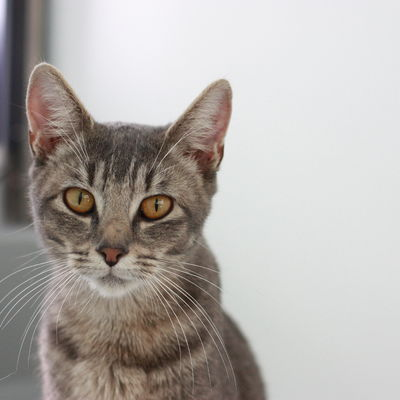

In [3]:
im = Image.open(IMAGE_PATH)
print(type(im))
display(im)

<PIL.Image.Image image mode=RGB size=224x224 at 0x7F5A4506A830>


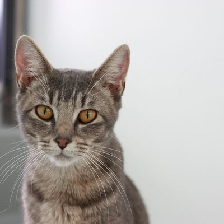

In [4]:
im = keras.preprocessing.image.load_img(IMAGE_PATH, target_size=dims) # -> PIL image
print(im)
display(im)


In [5]:
doc = keras.preprocessing.image.img_to_array(im) # -> numpy array
print(type(doc), doc.shape)


<class 'numpy.ndarray'> (224, 224, 3)


In [6]:
doc = np.expand_dims(doc, axis=0)
print(type(doc), doc.shape)
mobilenet_v2.preprocess_input(doc)
print(type(doc), doc.shape)

<class 'numpy.ndarray'> (1, 224, 224, 3)
<class 'numpy.ndarray'> (1, 224, 224, 3)


In [7]:
predictions = model.predict(doc)
print(type(predictions), predictions.shape)

<class 'numpy.ndarray'> (1, 1000)


In [8]:
top = mobilenet_v2.decode_predictions(predictions)
top_indices = np.argsort(predictions)[0, ::-1][:5]

print(top)
print(top_indices)


[[('n02123045', 'tabby', 0.44296435), ('n02124075', 'Egyptian_cat', 0.20841584), ('n02123159', 'tiger_cat', 0.17463905), ('n02127052', 'lynx', 0.004203083), ('n02123597', 'Siamese_cat', 0.0023852396)]]
[281 285 282 287 284]


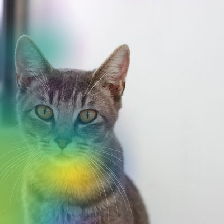

In [9]:
cat_idx = 282 # ImageNet ID for "tiger_cat" class, because we have a cat in the picture
eli5.show_prediction(model, doc, targets=[cat_idx]) # pass the class id